#### Irrigation Need Prediction in Nepal

This notebook presents the machine learning workflow for predicting irrigation need levels in Nepal as a 3-class classification problem:

- Low
- Medium
- High

### Objectives
- Prepare and inspect the dataset
- Apply feature engineering
- Train 3 classification models
- Compare performance before and after SMOTE
- Select the best final model

In [12]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Using project root:", PROJECT_ROOT)

Using project root: c:\swikrit\data science\Machine learning_sftwrca\nepal-irrigation-ml


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_utils import load_train_data, load_test_data, check_data
from src.preprocessing import split_data, add_features, build_pipeline
from src.models import get_models
from src.evaluate import evaluate_model, save_results_summary

In [14]:
train_df = load_train_data()
test_df = load_test_data()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (630000, 21)
Test shape: (270000, 20)


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid (Chaite),Drip,River,0.82,No,112.16,Eastern (Purwanchal),Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Rabi (Hiunde),Canal,Groundwater,5.27,Yes,47.16,Far-Western (Sudur-Pashchimanchal),Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif (Barkhe),Canal,Rainwater,8.24,Yes,110.38,Mid-Western (Madhya-Pashchimanchal),Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Rabi (Hiunde),Sprinkler,Groundwater,8.32,Yes,53.85,Far-Western (Sudur-Pashchimanchal),Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi (Hiunde),Canal,Groundwater,7.37,No,93.19,Far-Western (Sudur-Pashchimanchal),Low


In [15]:
check_data(train_df, "train")
check_data(test_df, "test")


TRAIN SHAPE: (630000, 21)

Columns:
['id', 'Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare', 'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need']

Missing values:
id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need     

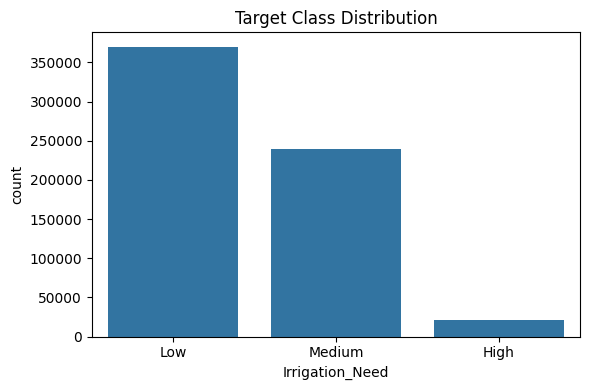

In [16]:
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x="Irrigation_Need")
plt.title("Target Class Distribution")
plt.tight_layout()
plt.show()

##### Feature Engineering

The following derived features are created:

- Moisture_Deficit
- Soil_Stress_Score
- Temp_Rainfall_Ratio
- Irrigation_Per_Hectare

In [17]:
train_fe = add_features(train_df)
train_fe.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need,Moisture_Deficit,Soil_Stress_Score,Temp_Rainfall_Ratio,Irrigation_Per_Hectare
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,River,0.82,No,112.16,Eastern (Purwanchal),Low,18.03,5.13,0.020647,61.626374
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Groundwater,5.27,Yes,47.16,Far-Western (Sudur-Pashchimanchal),Low,11.25,2.08,0.023230,7.521531
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rainwater,8.24,Yes,110.38,Mid-Western (Madhya-Pashchimanchal),Low,64.51,4.14,0.012244,11.945887
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Groundwater,8.32,Yes,53.85,Far-Western (Sudur-Pashchimanchal),Medium,48.25,2.22,0.009806,5.777897
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Groundwater,7.37,No,93.19,Far-Western (Sudur-Pashchimanchal),Low,31.97,1.92,0.013137,11.133811


In [18]:
X_train, X_valid, y_train, y_valid = split_data(train_df)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)

X_train: (504000, 23)
X_valid: (126000, 23)
y_train: (504000,)
y_valid: (126000,)


##### Baseline Model Training (Without SMOTE)

In [19]:
models = get_models()
baseline_results = []

for model_name, model in models.items():
    pipeline = build_pipeline(model)
    result = evaluate_model(
        model=pipeline,
        X_train=X_train,
        y_train=y_train,
        X_valid=X_valid,
        y_valid=y_valid,
        model_name=model_name,
        experiment_name="baseline_notebook"
    )
    baseline_results.append(result)

baseline_df = pd.DataFrame(baseline_results).sort_values(by="macro_f1", ascending=False)
baseline_df


===== Logistic Regression | baseline_notebook =====
Accuracy: 0.8430
Macro Precision: 0.7059
Macro Recall: 0.8509
Macro F1: 0.7435

Classification Report:
              precision    recall  f1-score   support

        High       0.38      0.89      0.53      4202
         Low       0.93      0.88      0.91     73983
      Medium       0.80      0.78      0.79     47815

    accuracy                           0.84    126000
   macro avg       0.71      0.85      0.74    126000
weighted avg       0.87      0.84      0.85    126000


===== Decision Tree | baseline_notebook =====
Accuracy: 0.9815
Macro Precision: 0.9394
Macro Recall: 0.9671
Macro F1: 0.9523

Classification Report:
              precision    recall  f1-score   support

        High       0.84      0.94      0.89      4202
         Low       0.99      0.99      0.99     73983
      Medium       0.99      0.96      0.98     47815

    accuracy                           0.98    126000
   macro avg       0.94      0.97      0.

,experiment,model,accuracy,macro_precision,macro_recall,macro_f1
2,baseline_notebook,Random Forest,0.984976,0.967966,0.967736,0.967831
1,baseline_notebook,Decision Tree,0.981524,0.939396,0.967119,0.952335
0,baseline_notebook,Logistic Regression,0.842952,0.705882,0.850883,0.743525


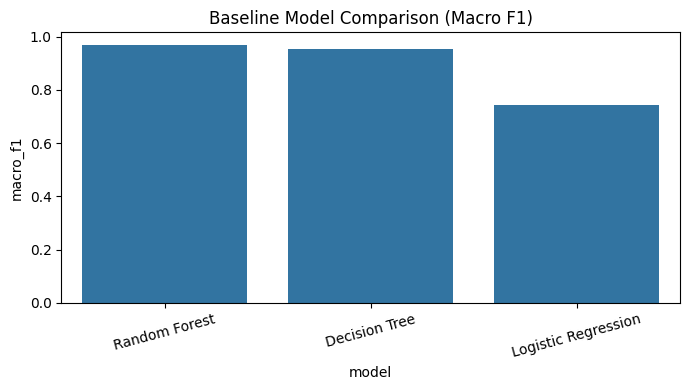

In [20]:
plt.figure(figsize=(7, 4))
sns.barplot(data=baseline_df, x="model", y="macro_f1")
plt.title("Baseline Model Comparison (Macro F1)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

##### SMOTE Model Results
The SMOTE experiments were executed through the project scripts and saved to CSV.

In [24]:
baseline_summary = pd.read_csv("C:\swikrit\data science\Machine learning_sftwrca\/nepal-irrigation-ml\outputs\metrics\/baseline_summary.csv")
smote_summary = pd.read_csv("C:\swikrit\data science\Machine learning_sftwrca\/nepal-irrigation-ml\outputs\metrics\smote_summary.csv")
comparison_summary = pd.read_csv("C:\swikrit\data science\Machine learning_sftwrca\/nepal-irrigation-ml\outputs\metrics\/all_model_comparison.csv")

baseline_summary, smote_summary

<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\Swikrit\AppData\Local\Temp\ipykernel_11548\2701142735.py:1: SyntaxWarning

(  experiment                model  accuracy  macro_precision  macro_recall  \
 0   baseline        Random Forest  0.984976         0.967966      0.967736   
 1   baseline        Decision Tree  0.981524         0.939396      0.967119   
 2   baseline  Logistic Regression  0.842952         0.705882      0.850883   
 
    macro_f1  
 0  0.967831  
 1  0.952335  
 2  0.743525  ,
   experiment                model  accuracy  macro_precision  macro_recall  \
 0      smote        Random Forest  0.983278         0.961912      0.965573   
 1      smote        Decision Tree  0.982405         0.947596      0.963790   
 2      smote  Logistic Regression  0.708746         0.589325      0.740072   
 
    macro_f1  
 0  0.963708  
 1  0.955335  
 2  0.622372  )

In [25]:
comparison_summary

,experiment,model,accuracy,macro_precision,macro_recall,macro_f1
0,baseline,Random Forest,0.984976,0.967966,0.967736,0.967831
1,smote,Random Forest,0.983278,0.961912,0.965573,0.963708
2,smote,Decision Tree,0.982405,0.947596,0.963790,0.955335
3,baseline,Decision Tree,0.981524,0.939396,0.967119,0.952335
4,baseline,Logistic Regression,0.842952,0.705882,0.850883,0.743525
5,smote,Logistic Regression,0.708746,0.589325,0.740072,0.622372


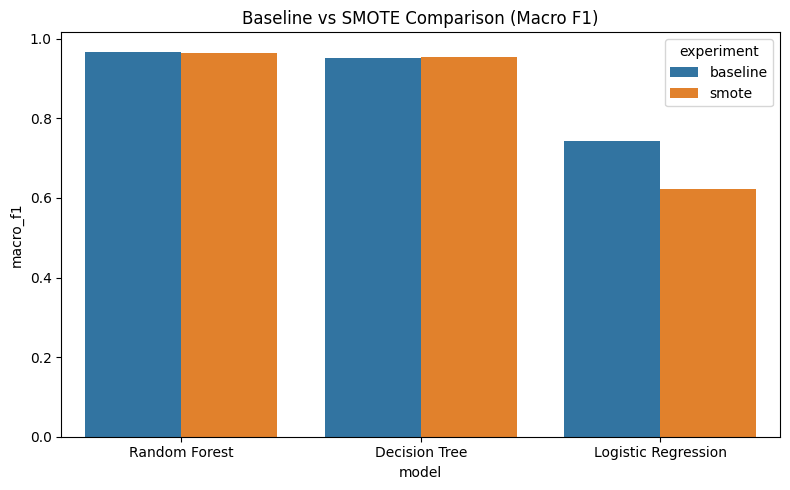

In [26]:
plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_summary, x="model", y="macro_f1", hue="experiment")
plt.title("Baseline vs SMOTE Comparison (Macro F1)")
plt.tight_layout()
plt.show()

##### Final Findings

- Random Forest achieved the best overall performance.
- Baseline Random Forest performed slightly better than SMOTE Random Forest.
- Decision Tree improved slightly after SMOTE.
- Logistic Regression performed worse after SMOTE.
- Therefore, the final selected model is the baseline Random Forest.

In [28]:
final_predictions = pd.read_csv("C:\swikrit\data science\Machine learning_sftwrca\/nepal-irrigation-ml\outputs\predictions\/final_test_predictions.csv")
final_predictions.head()

<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\Swikrit\AppData\Local\Temp\ipykernel_11548\623860028.py:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  final_predictions = pd.read_csv("C:\swikrit\data science\Machine learning_sftwrca\/nepal-irrigation-ml\outputs\predictions\/final_test_predictions.csv")


,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low


##### Conclusion

This notebook demonstrated the complete machine learning workflow for irrigation need prediction in Nepal.  
Three classification models were evaluated before and after SMOTE.  
Based on macro F1-score and overall class balance, the baseline Random Forest was selected as the final model.